# Imports and loads

In [1]:
import sys
import yaml
import json
import numpy as np
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
root = Path.cwd().parent.parent
sys.path.append(str(root))
plt.rcParams.update({"text.usetex": True, "font.family": "Computer Modern"}) 
from train import Trainer
from data.data_set import DataSet
from utils.readable import eval_metric_latex, dataset_latex

figure_path = Path('/mnt/c/users/rdsup/desktop/1st-paper/figures')
das_path = Path('/mnt/c/users/rdsup/desktop/DAS2026')

with open(root / "configs" / "generators.yaml", "r") as f:
    config = yaml.safe_load(f)

with open(root  / "data" / "data_sets.yaml" , "r") as f:
    datasets = yaml.safe_load(f)

train_inp_names = datasets["train"]
eval_rand_inp_names = datasets["eval"]["rand"]
eval_crit_inp_names = datasets["eval"]["crit"]

In [2]:
# Find trained models
mat_name = 'isotropic-swift'
train_inp_name = 'pd_ms_42_200'

train_set = DataSet(mat_name,'train',train_inp_name)

model_folder = Path(root,'metrics',mat_name,train_inp_name)
model_dirs = list(model_folder.iterdir())

eval_results = []
trainers = []

for model_dir in tqdm(model_dirs):

    trainer = Trainer(
        dataset=train_set,
        config_path='../../configs/train.yaml',
    ) # Empty trainer
    trainer.load(model_dir/'model.pth')
    trainers.append(trainer)

    eval_metrics_path = Path(model_folder,trainer.model.name,'eval_metrics.json')
    
    with open(eval_metrics_path,'rb') as f:
        error_metrics = json.load(f)

    name = "AR-MLP" if trainer.model.network_name == 'MLP' else "LSTM"
    mode = "Res-" if trainer.model.incr else ""
    model_family = f"{mode}{name}"


    for eval_set, err_types_dict in error_metrics.items():
        for err_type, err_measures_dict in err_types_dict.items():
            for err_measure, value in err_measures_dict.items():
                eval_results.append({
                    'name': model_family,
                    'network': trainer.model.network_name,
                    'k': trainer.model.k,
                    'p': trainer.model.p,
                    'q': trainer.model.q,
                    'num_params': trainer.model.num_params,
                    'num_states': (trainer.model.k if trainer.model.network_name == 'MLP' else 2*trainer.model.p*trainer.model.q),
                    'eval_set': eval_set,
                    'err_type': err_type,
                    'err_measure': err_measure,
                    'value': value
                })

df_master = pd.DataFrame(eval_results)

df_wide = df_master.pivot_table(
    index=['name', 'network', 'k', 'p', 'q', 'num_params', 'num_states', 'err_type', 'err_measure'], 
    columns='eval_set', 
    values='value'
).reset_index()

groups = df_wide.groupby(['err_type','err_measure'])

100%|██████████| 184/184 [00:06<00:00, 28.74it/s]


In [3]:
df_tmp = groups.get_group(('global','RMSE'))
stats = df_tmp.groupby('name')['num_params'].agg(['min', 'max']).to_dict(orient='index')
print(json.dumps(stats, indent=4))

{
    "AR-MLP": {
        "min": 15,
        "max": 585
    },
    "LSTM": {
        "min": 43,
        "max": 1097
    },
    "Res-AR-MLP": {
        "min": 15,
        "max": 585
    },
    "Res-LSTM": {
        "min": 59,
        "max": 1097
    }
}


# Visualizations

### Train and Validation MSE vs Epoch (training curves)

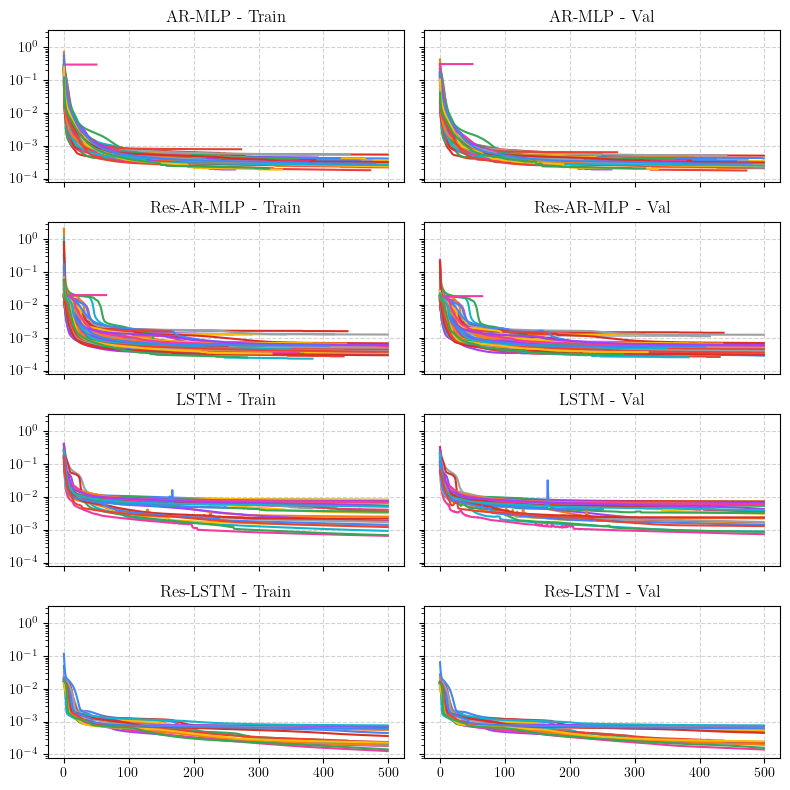

In [10]:
fig, ax = plt.subplots(4,2,figsize=(8,8),dpi=100,sharex=True,sharey=True)

for trainer in trainers:
    if not trainer.model.incr and trainer.model.network_name == 'MLP' : 
        ax[0,0].plot(trainer.train_losses)
        ax[0,1].plot(trainer.val_losses)
    if trainer.model.incr and trainer.model.network_name == 'MLP' : 
        ax[1,0].plot(trainer.train_losses)
        ax[1,1].plot(trainer.val_losses)
    if not trainer.model.incr and trainer.model.network_name == 'LSTM': 
        ax[2,0].plot(trainer.train_losses)
        ax[2,1].plot(trainer.val_losses)
    if trainer.model.incr and trainer.model.network_name == 'LSTM': 
        ax[3,0].plot(trainer.train_losses)
        ax[3,1].plot(trainer.val_losses)


ax[0,0].set_title('AR-MLP - Train')
ax[0,1].set_title('AR-MLP - Val')
ax[1,0].set_title('Res-AR-MLP - Train')
ax[1,1].set_title('Res-AR-MLP - Val')
ax[2,0].set_title('LSTM - Train')
ax[2,1].set_title('LSTM - Val')
ax[3,0].set_title('Res-LSTM - Train')
ax[3,1].set_title('Res-LSTM - Val')
    
for a in ax.flatten(): 
    a.set_yscale('log')
    a.grid(ls='--',color='lightgray')

plt.tight_layout()
plt.show()

### Distribution of local and global RMSE of model families (boxplots)

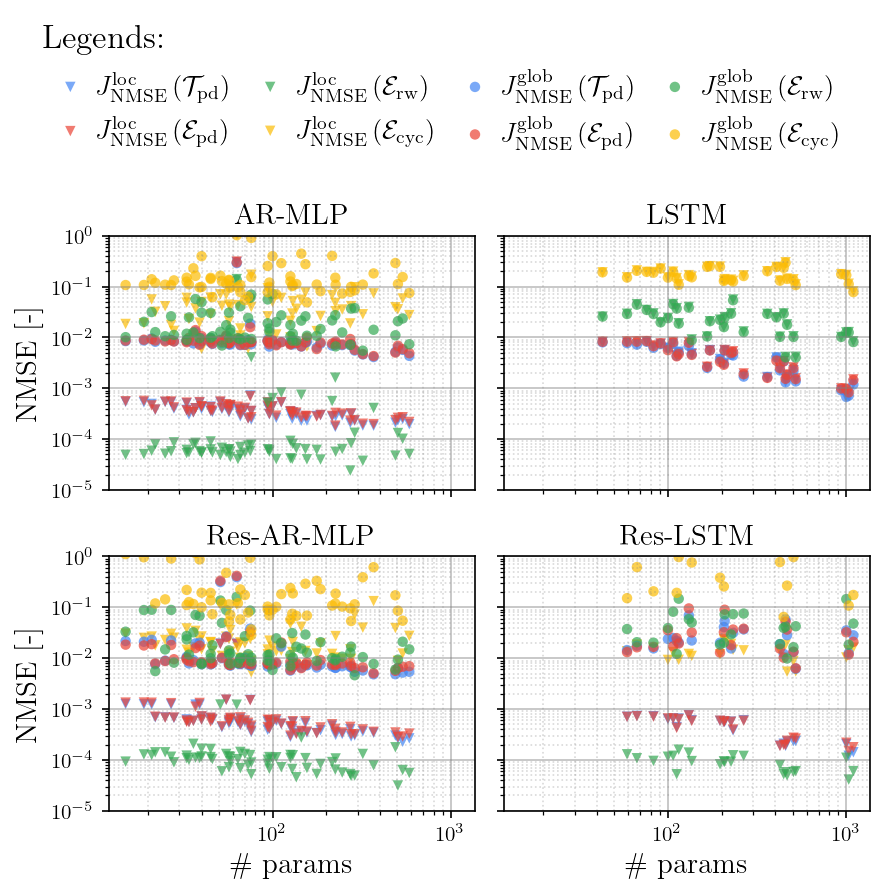

In [ ]:
observed_datasets = [
    ('pd_ms_42_200','train', '#4285F4'),
    ('pd_ms_56_20','eval', '#EA4335'),
    ('rw_56_20','eval', '#34A853'),
    ('cyclic','eval', '#FBBC05'),
]

err_types = [
    ('local','v'),
    ('global','o')
]
err_measure = 'RMSE'

fig, ax = plt.subplots(2,2,figsize=(6,6),dpi=150,sharex=True, sharey=True)
ax = ax.flatten()

for err_type, marker in err_types:
    df = groups.get_group((err_type,err_measure))
    for i, (name, df_tmp) in enumerate(df.groupby('name')):

        for inp_name, inp_type, c in observed_datasets:
            ax[i].scatter(
                df_tmp['num_params'], df_tmp[inp_name], 
                label=eval_metric_latex(inp_type, inp_name, err_measure=err_measure, err_type=err_type), 
                s=25, c=c,marker=marker, alpha=0.7, edgecolors='none'
            )
         
        ax[i].set_xscale('log')
        ax[i].set_yscale('log')
        ax[i].set_title(name, fontsize=14)
        ax[i].set_ylim(1e-5, 1e0)
        ax[i].grid(True, which='major', color='gray', linestyle='-', alpha=0.5)
        ax[i].grid(True, which='minor', color='gray', linestyle=':', alpha=0.3)

ax[0].set_ylabel('NMSE [-]', fontsize=14)
ax[2].set_ylabel('NMSE [-]', fontsize=14)
ax[2].set_xlabel('\\# params', fontsize=14)
ax[3].set_xlabel('\\# params', fontsize=14)

handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), 
    by_label.keys(),
    title="Legends:",
    title_fontsize='16',
    alignment='left',
    loc='upper center', 
    bbox_to_anchor=(0.5, 1),
    fontsize=13, 
    ncol=4,
    columnspacing=0.4,
    handletextpad=0,
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.8])
plt.show()

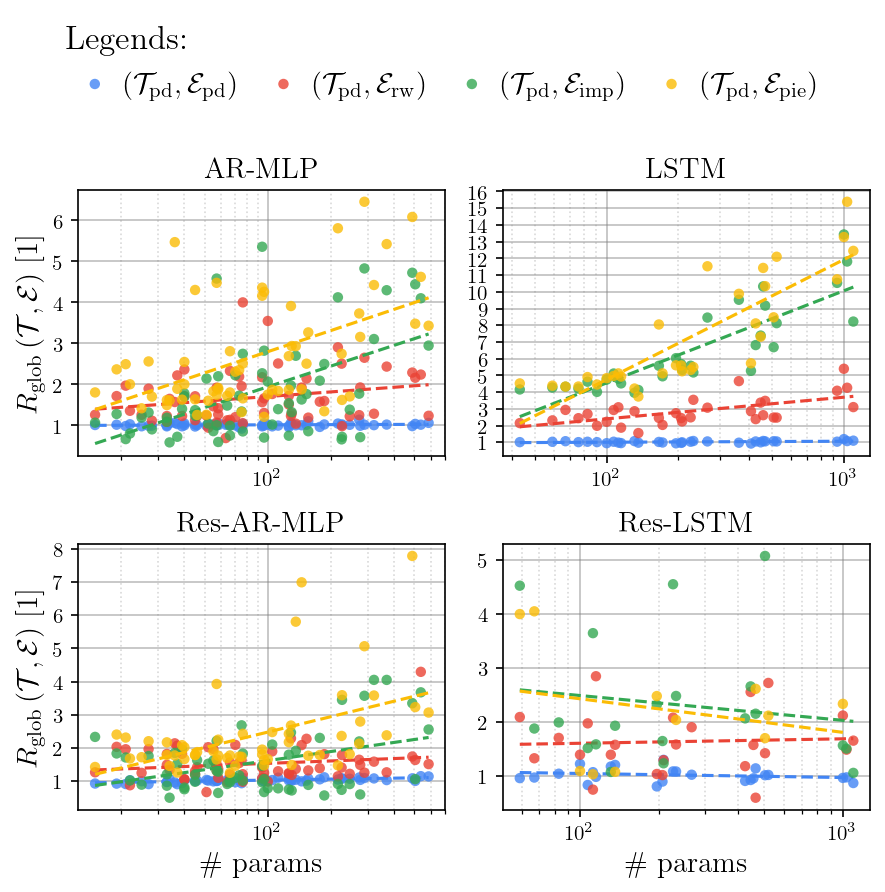

In [12]:
observed_datasets = [
    ('pd_ms_56_20','#4285F4'),
    ('rw_42_200','#EA4335'),
    ('impulse','#34A853'),
    ('piecewise','#FBBC05'),
]

err_types = [('global','RMSE','o')]

fig, ax = plt.subplots(2,2,figsize=(6,6),dpi=150)
ax = ax.flatten()

for err_type, err_measure, marker in err_types:
    df = groups.get_group((err_type, err_measure))
    for i, (name, df_tmp) in enumerate(df.groupby('name')):

        for inp_name, c in observed_datasets:

            mask = (df_tmp[inp_name]  <= 1e8) & (df_tmp['pd_ms_42_200']  <= 1e8)

            df_filtered = df_tmp[mask].copy()

            # print(f"{name} & {inp_name}: {df_filtered[inp_name].max()/1e6:.2f}, {df_filtered['pd_ms_42_200'].min()/1e6:.2f}")

            x_data = df_filtered['num_params'].values
            y_data = (df_filtered[inp_name] / df_filtered['pd_ms_42_200']).values
            

            # label = eval_metric_latex('eval', inp_name, err_measure='NMSE', err_type='local')
            # label += '/'
            # label += eval_metric_latex('train', 'pd_ms_42_200', err_measure='NMSE', err_type='local')

            trainset = dataset_latex('train','pd_ms_42_200')[1:-1]
            evalset = dataset_latex('eval', inp_name)[1:-1]


            label = rf'$\left({{{trainset}}}, {{{evalset}}}\right)$'

            # Scatter plot
            ax[i].scatter(
                x_data, y_data, 
                label=label, 
                s=25, c=c, marker=marker, alpha=0.8, edgecolors='none', zorder=2
            )

            # ax[i].set_ylim(0.5, 1.5e1)

            valid = (x_data > 0) & (y_data > 0)
            if valid.sum() > 1:
                x_valid = x_data[valid]
                y_valid = y_data[valid]
                
                # Fit 1st degree polynomial to the log10 of the data
                m, b = np.polyfit(np.log10(x_valid), y_valid, 1)
                
                # Generate x values for the fit line and convert y back from log space
                x_fit = np.linspace(x_valid.min(), x_valid.max(), 100)
                y_fit = m * np.log10(x_fit) + b
                
                # Plot the fit line
                ax[i].plot(x_fit, y_fit, color=c, alpha=1, linestyle='--')
        
        ax[i].set_xscale('log')
        # ax[i].set_yscale('log')
        ax[i].set_title(name, fontsize=14)
        ax[i].grid(True, which='major', color='gray', linestyle='-', alpha=0.5)
        ax[i].grid(True, which='minor', color='gray', linestyle=':', alpha=0.3)
        ax[i].yaxis.set_major_locator(ticker.MultipleLocator(1))
        # ax[i].axhline(y=1.0, color='black', linestyle='-', linewidth=1.5, zorder=1)
        

ax[0].set_ylabel(r"$R_{\mathrm{glob}}\left(\mathcal{T},\mathcal{E}\right)$ [1]", fontsize=14)
ax[2].set_ylabel(r"$R_{\mathrm{glob}}\left(\mathcal{T},\mathcal{E}\right)$ [1]", fontsize=14)
ax[2].set_xlabel('\\# params', fontsize=14)
ax[3].set_xlabel('\\# params', fontsize=14)


handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), 
    by_label.keys(),
    title="Legends:",
    title_fontsize='16',
    alignment='left',
    loc='upper center', 
    bbox_to_anchor=(0.5, 1),
    fontsize=14, 
    ncol=4,
    columnspacing=0.5,
    handletextpad=0,
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.85])

plt.savefig(figure_path / 'grid-search-overfitting.svg', format='svg', bbox_inches='tight')
plt.savefig(figure_path / 'grid-search-overfitting.pdf', bbox_inches='tight')

plt.show()

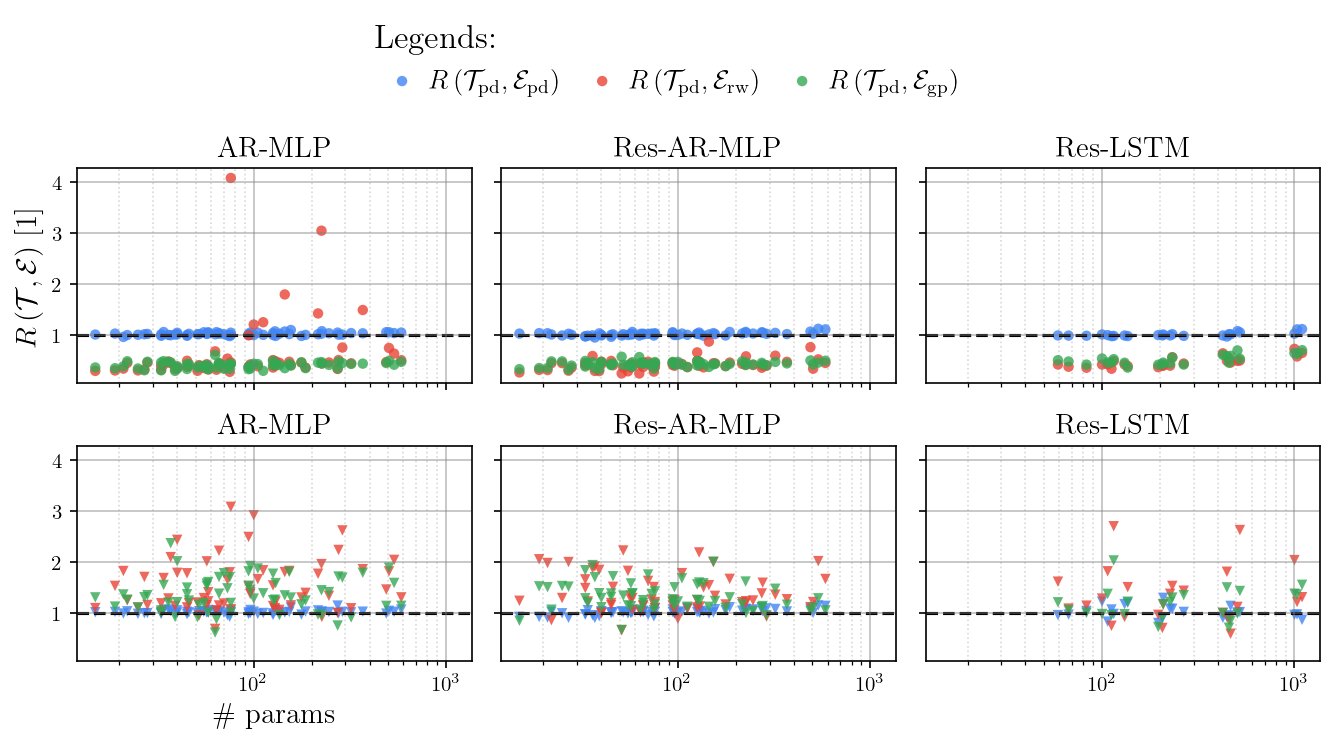

In [13]:
observed_datasets = [
    ('pd_ms_56_20','#4285F4'),
    ('rw_56_20','#EA4335'),
    ('gp_56_20','#34A853'),
]

err_types = [
    ('local','RMSE','o'),
    ('global','RMSE','v')
]

fig, ax = plt.subplots(2,3,figsize=(9,5),dpi=150, sharey=True, sharex=True)

j = 0
for err_type, err_measure, marker in err_types:
    df = groups.get_group((err_type, err_measure))
    i = 0
    for name, df_tmp in df.groupby('name'):
        
        if name != 'LSTM':
            for inp_name, c in observed_datasets:

                mask = (df_tmp[inp_name]  <= 1e8) & (df_tmp['pd_ms_42_200']  <= 1e8)

                df_filtered = df_tmp[mask].copy()

                # print(f"{name} & {inp_name}: {df_filtered[inp_name].max()/1e6:.2f}, {df_filtered['pd_ms_42_200'].min()/1e6:.2f}")

                x_data = df_filtered['num_params'].values
                y_data = (df_filtered[inp_name] / df_filtered['pd_ms_42_200']).values
                

                # label = eval_metric_latex('eval', inp_name, err_measure='NMSE', err_type='local')
                # label += '/'
                # label += eval_metric_latex('train', 'pd_ms_42_200', err_measure='NMSE', err_type='local')

                trainset = dataset_latex('train','pd_ms_42_200')[1:-1]
                evalset = dataset_latex('eval', inp_name)[1:-1]


                label = rf'$R\left({{{trainset}}}, {{{evalset}}}\right)$'

                # Scatter plot
                ax[j,i].scatter(
                    x_data, y_data, 
                    label=label, 
                    s=25, c=c, marker=marker, alpha=0.8, edgecolors='none'
                )

                # ax[i].set_ylim(0.5, 1.5e1)
            
            ax[j,i].set_xscale('log')
            # ax[i].set_yscale('log')
            ax[j,i].set_title(name, fontsize=14)
            ax[j,i].grid(True, which='major', color='gray', linestyle='-', alpha=0.5)
            ax[j,i].grid(True, which='minor', color='gray', linestyle=':', alpha=0.3)
            ax[j,i].axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, zorder=1)
            i+=1
    j += 1

ax[0,0].set_ylabel(r"$R\left(\mathcal{T},\mathcal{E}\right)$ [1]", fontsize=14)
ax[1,0].set_xlabel('\\# params', fontsize=14)
ax[1,0].set_xlabel('\\# params', fontsize=14)


handles, labels = ax[0,0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), 
    by_label.keys(),
    title="Legends:",
    title_fontsize='16',
    alignment='left',
    loc='upper center', 
    bbox_to_anchor=(0.5, 1),
    fontsize=13, 
    ncol=4,
    columnspacing=0.5,
    handletextpad=0,
    frameon=False,
)
plt.tight_layout(rect=[0, 0, 1, 0.85])

# plt.savefig(figure_path / 'grid-search-overfitting.svg', format='svg', bbox_inches='tight')
# plt.savefig(figure_path / 'grid-search-overfitting.pdf', bbox_inches='tight')

plt.show()

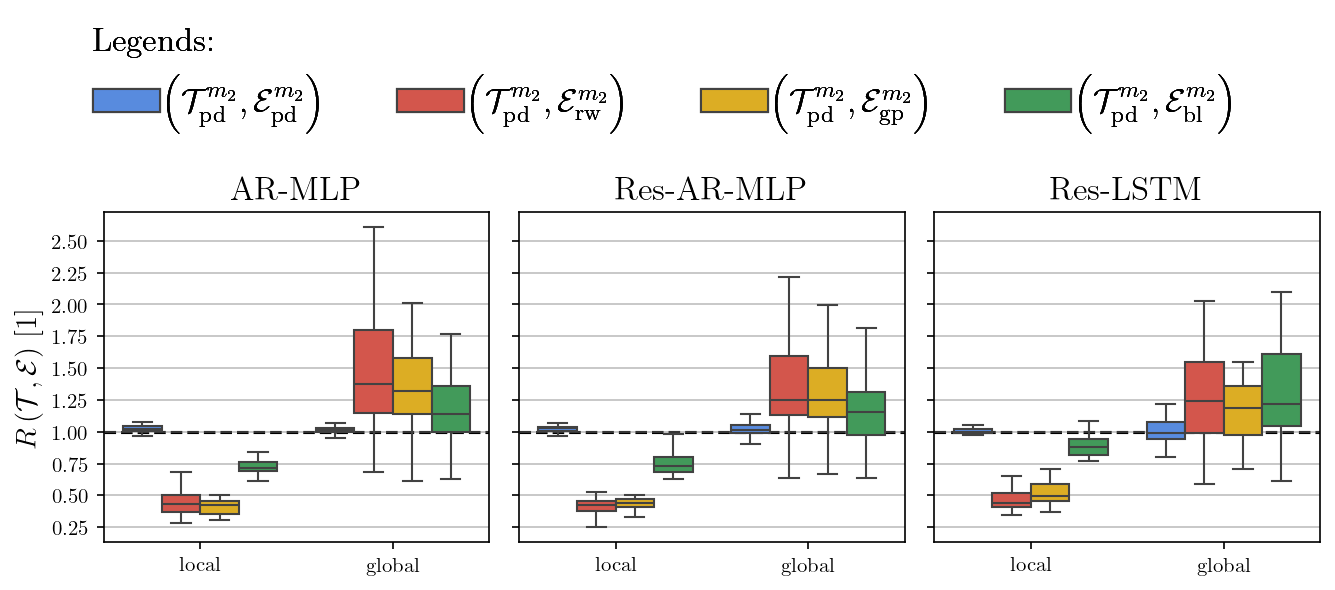

In [14]:
err_measure = 'RMSE'
observed_datasets = ['pd_ms_56_20', 'rw_56_20', 'gp_56_20', 'bl_ms_56_20']


df = df_wide[['name', 'num_params', 'err_type', 'err_measure', 'pd_ms_42_200'] + observed_datasets]
df = df[(df['err_measure'] == err_measure) & (df['name'] != 'LSTM')]

for observed_dataset in observed_datasets:
    df[observed_dataset] = df[observed_dataset] / df['pd_ms_42_200']

df = df.drop(columns=['pd_ms_42_200', 'err_measure'])


# 1. Reshape the DataFrame to long format
df_long = df.melt(
    id_vars=['name', 'err_type'],
    value_vars=observed_datasets,
    var_name='metric',
    value_name='overfitting_ratio'
)

# 2. Initialize a 1x3 subplot grid (one for each category in 'name')
categories = df_long['name'].unique()
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True,dpi=150)

# Define explicit ordering for consistent comparison layout
err_order = ['local', 'global']
hue_order = observed_datasets

# 3. Iterate through categories and plot
for ax, cat in zip(axes, categories):
    # Filter data for the specific category
    df_cat = df_long[df_long['name'] == cat]
    
    # Render the boxplot
    sns.boxplot(
        data=df_cat,
        x='err_type',
        y='overfitting_ratio',
        hue='metric',
        order=err_order,
        hue_order=hue_order,
        ax=ax,
        showfliers=False
    )
    
    # Configure subplot metadata
    ax.set_title(f"{cat}", fontsize=16, fontweight='bold')
    ax.set_xlabel("")
    
    # Label y-axis only on the leftmost plot due to sharey=True
    if ax == axes[0]:
        ax.set_ylabel(r"$R\left(\mathcal{T},\mathcal{E}\right)$ [1]", fontsize=14)
    else:
        ax.set_ylabel("")
        
    ax.get_legend().remove()
    ax.yaxis.grid(True, which='major', color='gray', linestyle='-', alpha=0.5)
    ax.yaxis.grid(True, which='minor', color='gray', linestyle=':', alpha=0.3)
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, zorder=1)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))

    handles, labels = ax.get_legend_handles_labels()

    labels = [
        rf'$\left({dataset_latex('train','pd_ms_42_200','isotropic-swift')[1:-1]},{dataset_latex('eval',label,'isotropic-swift')[1:-1]}\right)$'
        for label in labels if label
    ]

    fig.legend(
        handles=handles, 
        labels=labels, 
        title="Legends:",
        title_fontsize='16',
        alignment='left',
        loc='upper center', 
        bbox_to_anchor=(0.5, 1),
        fontsize=16, 
        ncol=4,
        columnspacing=2,
        handletextpad=0.2,
        frameon=False,
    )
plt.tight_layout(rect=[0, 0, 1, 0.74])

plt.savefig(figure_path / 'cross-generator-loc-vs-glob.svg',format='svg')
plt.savefig(figure_path / 'cross-generator-loc-vs-glob.pdf', bbox_inches='tight')

plt.show()

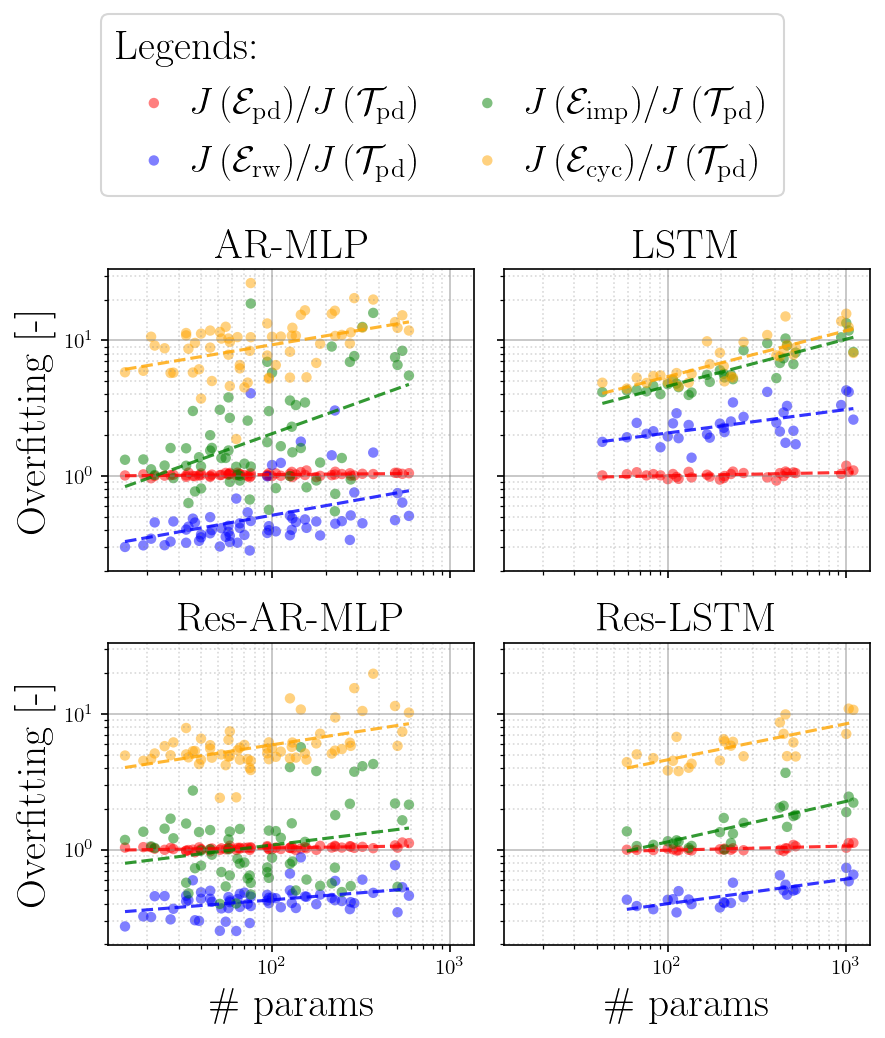

In [15]:
observed_datasets = [
    ('pd_ms_56_20','red'),
    ('rw_56_20','blue'),
    ('impulse','green'),
    ('cyclic','orange'),
]

err_types = [
    ('local','o'),
]

fig, ax = plt.subplots(2,2,figsize=(6,7),dpi=150,sharex=True, sharey=True)
ax = ax.flatten()

for err_type, marker in err_types:
    df = groups.get_group((err_type,'RMSE'))
    for i, (name, df_tmp) in enumerate(df.groupby('name')):

        for inp_name, c in observed_datasets:
            x_data = df_tmp['num_params'].values
            y_data = (df_tmp[inp_name] / df_tmp['pd_ms_42_200']).values
            
            label = eval_metric_latex('eval', inp_name)
            label += '/'
            label += eval_metric_latex('train', 'pd_ms_42_200')

            # Scatter plot
            ax[i].scatter(
                x_data, y_data, 
                label=label, 
                s=25, c=c, marker=marker, alpha=0.5, edgecolors='none'
            )

            valid = (x_data > 0) & (y_data > 0)
            if valid.sum() > 1:
                x_valid = x_data[valid]
                y_valid = y_data[valid]
                
                # Fit 1st degree polynomial to the log10 of the data
                m, b = np.polyfit(np.log10(x_valid), np.log10(y_valid), 1)
                
                # Generate x values for the fit line and convert y back from log space
                x_fit = np.linspace(x_valid.min(), x_valid.max(), 100)
                y_fit = 10**(m * np.log10(x_fit) + b)
                
                # Plot the fit line
                ax[i].plot(x_fit, y_fit, color=c, alpha=0.8, linestyle='--')
        
        ax[i].set_xscale('log')
        ax[i].set_yscale('log')
        ax[i].set_title(name, fontsize=20)
        ax[i].grid(True, which='major', color='gray', linestyle='-', alpha=0.5)
        ax[i].grid(True, which='minor', color='gray', linestyle=':', alpha=0.3)
        

ax[0].set_ylabel('Overfitting [-]', fontsize=20)
ax[2].set_ylabel('Overfitting [-]', fontsize=20)
ax[2].set_xlabel('\\# params', fontsize=20)
ax[3].set_xlabel('\\# params', fontsize=20)


handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(), 
    by_label.keys(),
    title="Legends:",
    title_fontsize='20',
    alignment='left',
    loc='upper center', 
    bbox_to_anchor=(0.5, 1),
    fontsize=18, 
    ncol=2,
    columnspacing=0.75,
    handletextpad=0,
    frameon=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.8])
plt.show()

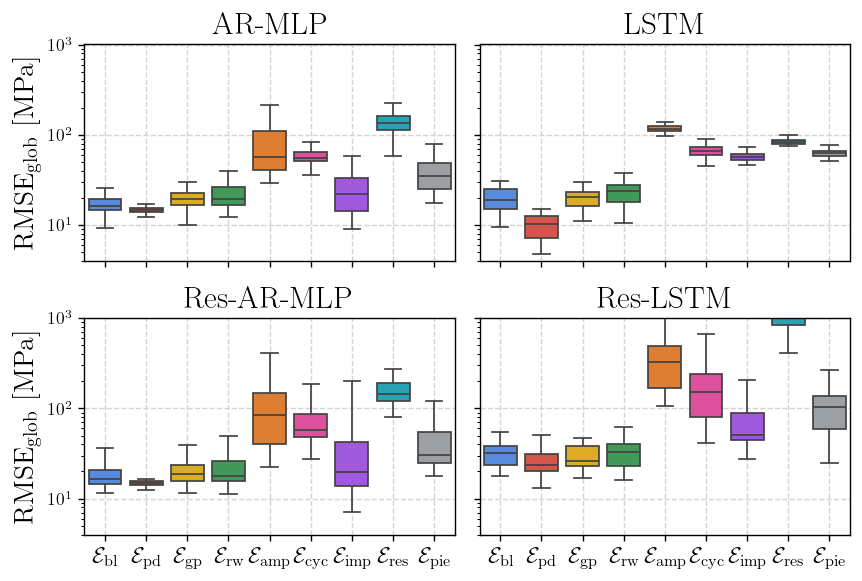

In [16]:
df = groups.get_group(('global','RMSE'))


# Create the 2x2 grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 4.75), sharex=True, sharey=True, dpi=125)
axes = axes.flatten() 

for (name, df_tmp), ax in zip(df.groupby('name'), axes):
    
    # Melt the dataframe so columns become rows (Seaborn loves this format)
    df_melted = df_tmp.melt(value_vars=eval_rand_inp_names + eval_crit_inp_names, 
                            var_name='Metric', 
                            value_name='Value')
    df_melted['Value'] = df_melted['Value'] / 1e6  # Convert to MPa for better readability
    df_melted['Metric'] = df_melted['Metric'].apply(lambda x: dataset_latex('eval',x,None))
    # Create the seaborn boxplot, removing outliers with showfliers=False
    sns.boxplot(data=df_melted, x='Metric', y='Value', hue='Metric', ax=ax, 
                showfliers=False, legend=False)
    
    # Clean up the formatting
    ax.set_title(f'{name}', fontsize=18, fontweight='bold')
    ax.set_xlabel('') # Clears the generic 'Metric' label to keep it tidy
    ax.set_ylabel(rf'$\mathrm{{RMSE}}_{{\mathrm{{glob}}}}$ [MPa]', fontsize=16)
    
    # Rotate x-axis labels if your metric names are long
    ax.tick_params(axis='x', rotation=0, labelsize=13)
    ax.set_yscale('log')
    ax.set_ylim(4e0, 1e3+10)  # Set y-axis limits for log scale
    ax.grid(ls='--',c='lightgray')

plt.tight_layout()
plt.savefig(figure_path / 'grid-search-global-rmse-boxplot.png', format='svg', bbox_inches='tight')
plt.savefig(figure_path / 'grid-search-global-rmse-boxplot.pdf', bbox_inches='tight')
plt.show()

### Pick the best model

In [4]:
eval_crit_inp_names

['amplitude', 'cyclic', 'impulse', 'resolution', 'piecewise']

In [25]:
eval_rand_inp_names

['bl_ms_56_20', 'pd_ms_56_20', 'gp_56_20', 'rw_56_20']

In [7]:
df

eval_set,name,network,k,p,q,num_params,num_states,err_type,err_measure,amplitude,...,cyclic,gp_42_200,gp_56_20,impulse,pd_ms_42_200,pd_ms_56_20,piecewise,resolution,rw_42_200,rw_56_20
3,AR-MLP,MLP,2,2,2,15,2,global,RMSE,4.703694e+07,...,5.369834e+07,1.899670e+07,1.966207e+07,1.613221e+07,1.511097e+07,1.527679e+07,2.728164e+07,1.704148e+08,1.904967e+07,1.650888e+07
11,AR-MLP,MLP,2,2,3,21,2,global,RMSE,5.314824e+07,...,6.122791e+07,2.404009e+07,2.177196e+07,1.070061e+07,1.602462e+07,1.580225e+07,3.997154e+07,1.794042e+08,3.157950e+07,2.913391e+07
19,AR-MLP,MLP,2,2,5,33,2,global,RMSE,3.773900e+07,...,6.339383e+07,1.751047e+07,1.596760e+07,1.663102e+07,1.526017e+07,1.528921e+07,2.283800e+07,1.545402e+08,1.661656e+07,1.553484e+07
27,AR-MLP,MLP,2,2,8,51,2,global,RMSE,7.884915e+07,...,6.633840e+07,1.617299e+07,1.418779e+07,3.325257e+07,1.550401e+07,1.543792e+07,1.956974e+07,1.192072e+08,1.924868e+07,1.862743e+07
35,AR-MLP,MLP,2,3,2,22,2,global,RMSE,4.183099e+07,...,5.645024e+07,1.999271e+07,1.870240e+07,1.196620e+07,1.487648e+07,1.530960e+07,2.982266e+07,1.679743e+08,2.020459e+07,1.850946e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,Res-LSTM,LSTM,5,3,2,232,12,global,RMSE,4.049106e+08,...,4.210485e+08,3.569794e+07,3.777098e+07,7.215587e+07,2.912584e+07,3.139014e+07,5.921720e+07,1.104222e+09,4.594666e+07,4.445483e+07
1443,Res-LSTM,LSTM,5,5,1,266,10,global,RMSE,1.692639e+09,...,3.793488e+08,4.007641e+07,4.237910e+07,1.318241e+08,3.147567e+07,3.201595e+07,2.449414e+08,6.816273e+09,5.974328e+07,4.508526e+07
1451,Res-LSTM,LSTM,5,5,2,506,20,global,RMSE,7.898017e+08,...,1.617200e+08,2.249056e+07,1.859125e+07,9.569482e+07,1.885835e+07,1.900497e+07,3.196728e+07,1.641674e+09,2.669814e+07,2.103248e+07
1459,Res-LSTM,LSTM,5,8,1,521,16,global,RMSE,3.354204e+08,...,1.836417e+08,2.008319e+07,1.841730e+07,1.093210e+08,1.290781e+07,1.308024e+07,2.726648e+07,4.456092e+08,3.509820e+07,3.382201e+07


IndexError: list index out of range

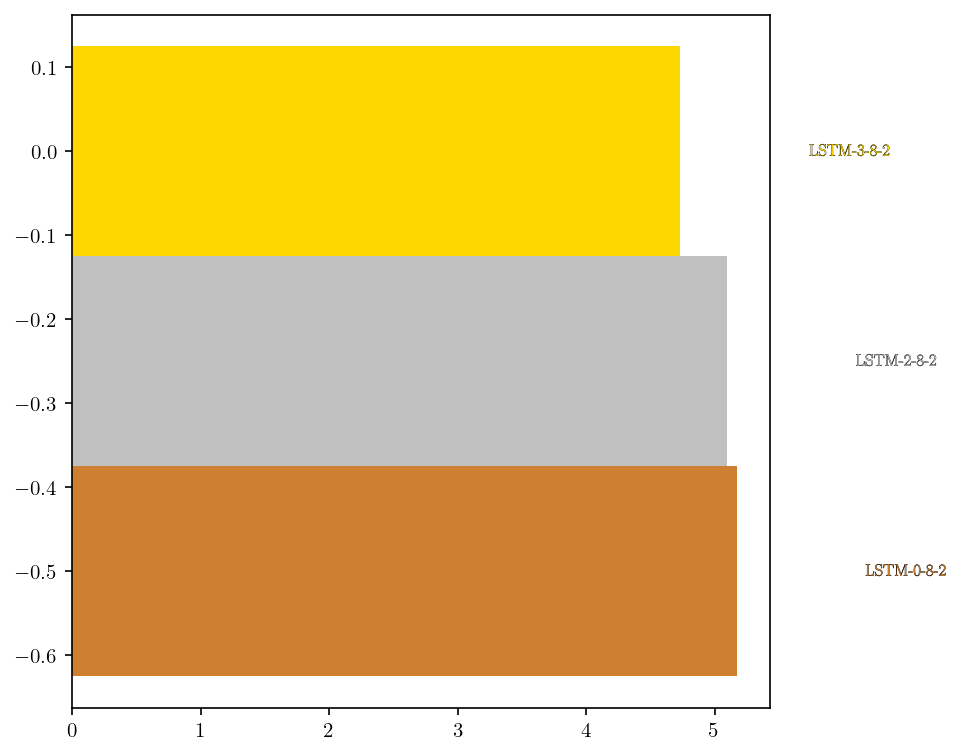

In [ ]:
df = groups.get_group(('global','RMSE'))


plot_data = []

import matplotlib.patheffects as path_effects

colors = ["#FFD700", "#C0C0C0", "#CD7F32"]

for eval_inp_name in eval_crit_inp_names + eval_rand_inp_names:
    top3 = df.sort_values(eval_inp_name).head(3)
    for _, row in top3.iterrows():
        plot_data.append({
            "test": eval_inp_name,
            "model": f"{row['name']}-{row['k']}-{row['p']}-{row['q']}",
            "error": row[eval_inp_name]
        })

plot_df = pd.DataFrame(plot_data)

# Now horizontal plot
# plot_df['test'] = plot_df['test'].apply(lambda x: eval_metric_latex('RMSE', 'global', mat_name, 'eval', x))
eval_inp_names = plot_df["test"].unique()
width = 0.25  # height of each bar

plt.figure(figsize=(6,6), dpi=150)

for i, test in enumerate(eval_inp_names):
    top3 = plot_df[plot_df["test"] == test].sort_values("error")
    y = np.arange(len(top3)) + i*(width*len(top3))
    for j, (_, row) in enumerate(top3.iterrows()):
        plt.barh(i - j*width, row["error"]/1e6, height=width, color=colors[j])
        txt = plt.text((row["error"]/1e6)+1, i - j*width, row["model"], va='center', ha='left', fontsize=8, color=colors[j])
        txt.set_path_effects([
            path_effects.Stroke(linewidth=0.25, foreground='black'),  # outline color & thickness
            path_effects.Normal()  # normal rendering of text
        ])     
# Set yticks in the middle of the grouped bars
plt.yticks([i - width for i in range(len(eval_inp_names))], eval_inp_names)
plt.xlabel("RMSE [MPa]")
plt.title("Top 4 models per evaluation set, for Isotropic-Swift material")
plt.xlim(0, 90)  # adjust to match your previous ylim
plt.tight_layout()
plt.show()


In [7]:
sets = ['pd_ms_56_20', 'cyclic']

df_tmp = df[['name','num_params', 'k', 'p', 'q'] + sets].copy()
df_tmp['avg'] = df_tmp[sets].mean(axis=1)
df_tmp.sort_values('avg')[:3]

eval_set,name,num_params,k,p,q,pd_ms_56_20,cyclic,avg
971,Res-AR-MLP,76,3,5,3,1.499794e+07,2.769558e+07,2.134676e+07
1075,Res-AR-MLP,76,5,3,5,1.419437e+07,3.147258e+07,2.283347e+07
867,Res-AR-MLP,57,2,8,2,1.414707e+07,3.763118e+07,2.588913e+07


In [9]:
sets = ['pd_ms_56_20']

df_tmp = df[['name','num_params', 'k', 'p', 'q'] + sets].copy()
df_tmp['avg'] = df_tmp[sets].mean(axis=1)
df_tmp.sort_values('avg')[:3]

eval_set,name,num_params,k,p,q,pd_ms_56_20,avg
699,LSTM,1033,3,8,2,4.732170e+06,4.732170e+06
635,LSTM,1001,2,8,2,5.095988e+06,5.095988e+06
571,LSTM,937,0,8,2,5.170046e+06,5.170046e+06


### By data set

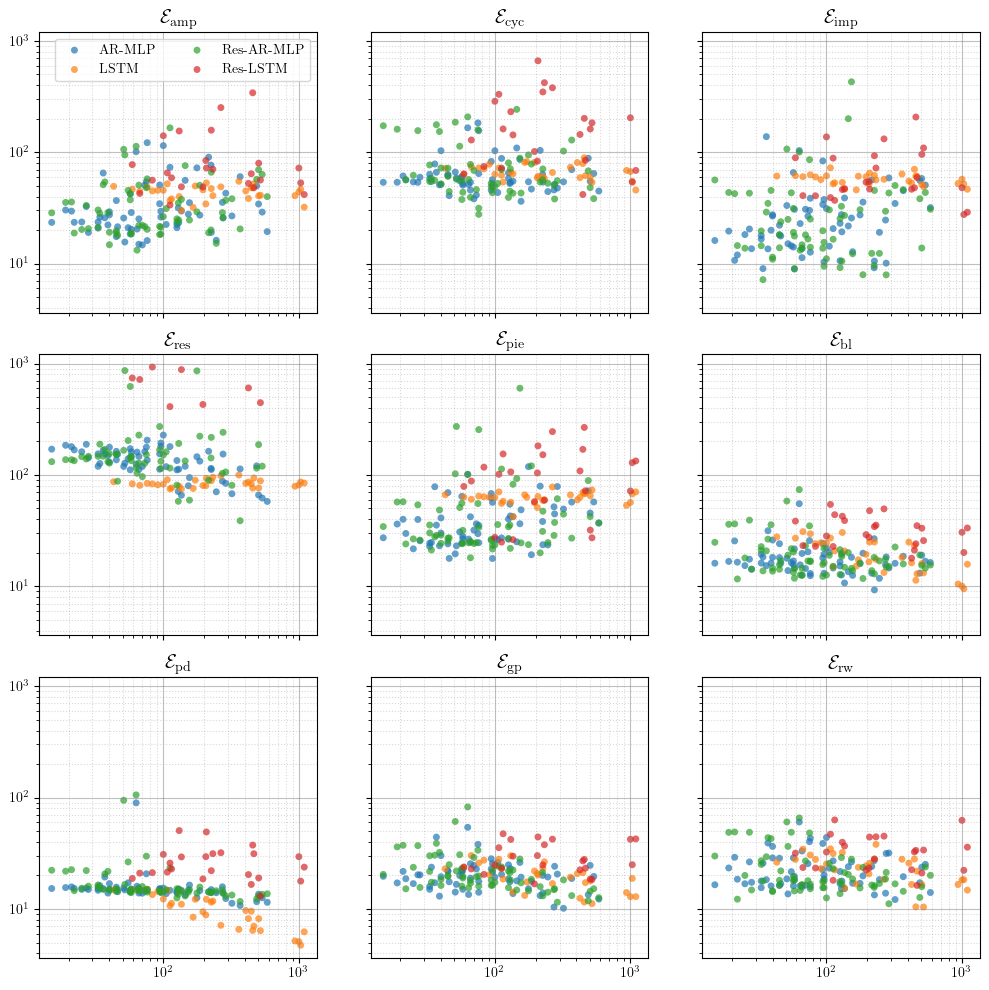

In [39]:
fig, ax = plt.subplots(3,3,figsize=(10,10),dpi=100,sharex=True,sharey=True)

ax = ax.flatten()

for i, eval_inp_name in enumerate(eval_crit_inp_names + eval_rand_inp_names):

    for name, df_tmp in df.groupby('name'):
        df_tmp[df_tmp[eval_inp_name] > 1e9] = np.nan
        ax[i].scatter(
            df_tmp['num_params'], df_tmp[eval_inp_name]/1e6, 
            label=name, 
            s=25, marker='o', alpha=0.7, edgecolors='none'
        )
        
        ax[i].set_yscale('log')
        ax[i].set_xscale('log')
        # ax[i].set_ylim(10e6,10e9)
        ax[i].set_title(dataset_latex('eval', eval_inp_name, None), fontsize=14)
        ax[i].grid(True, which='major', color='gray', linestyle='-', alpha=0.5)
        ax[i].grid(True, which='minor', color='gray', linestyle=':', alpha=0.3)

ax[0].legend(ncols=2)

plt.tight_layout()
plt.show()